# Paired Snapshot Graphs

Visualize the 22-node paired team graph (`features.build_graphs.build_snapshot_graph` with `mode="paired"`)
for a handful of real rows from `data/processed/lineup_snapshots.parquet`.

Each panel shows one snapshot:

- **Team 1** (blue) at its formation template coordinates.
- **Team 2** (red) at the 180° rotation of its template coordinates, so the two
  teams face each other across the halfway line and lane-aligned matchups
  line up physically on the pitch.
- **Blue / red edges**: each team's intra-team tactical rule edges
  (`graphs.templates.formation_edges`).
- **Orange edges**: inter-team matchup edges (`graphs.matchups.build_intermatch_edges`)
  e.g. strikers ↔ opposing center backs, winger ↔ opposing full-back.

Plotting logic lives in `graphs.visualize.draw_paired_graph`; this notebook
is intentionally thin so the helper can be reused elsewhere.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import math

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from graphs.templates import FORMATION_TEMPLATES
from graphs.visualize import draw_paired_graph

SNAPSHOTS = ROOT / 'data' / 'processed' / 'lineup_snapshots.parquet'
df = pd.read_parquet(SNAPSHOTS)
print(f'loaded {len(df):,} snapshots from {SNAPSHOTS.relative_to(ROOT)}')

loaded 79,782 snapshots from data\processed\lineup_snapshots.parquet


In [2]:
# Keep only rows we can build paired graphs for: both formations covered by a template,
# no null positions, no null archetypes.
pos_cols_1 = [f'team1_position_{i}' for i in range(1, 12)]
pos_cols_2 = [f'team2_position_{i}' for i in range(1, 12)]
arch_cols_1 = [f'team1_archetype_{i}' for i in range(1, 12)]
arch_cols_2 = [f'team2_archetype_{i}' for i in range(1, 12)]
label_cols = pos_cols_1 + pos_cols_2 + arch_cols_1 + arch_cols_2

allowed = set(FORMATION_TEMPLATES)
mask = (
    df['team1_formation'].isin(allowed)
    & df['team2_formation'].isin(allowed)
    & df[label_cols].notna().all(axis=1)
)
snaps = df.loc[mask].reset_index(drop=True)
print(f'{len(snaps):,} usable snapshots after filtering')

29,122 usable snapshots after filtering


In [3]:
# Hand-pick a few snapshots that show off varied formation matchups.
wanted_matchups = [
    ('4-3-3', '4-4-2'),
    ('4-2-3-1', '3-5-2'),
    ('3-4-3', '4-3-3'),
    ('5-3-2', '4-2-3-1'),
    ('4-4-2', '4-4-2'),
    ('3-4-1-2', '4-1-4-1'),
]

examples = []
for f1, f2 in wanted_matchups:
    hit = snaps[(snaps['team1_formation'] == f1) & (snaps['team2_formation'] == f2)]
    if hit.empty:
        # Fall back: swap the order if the desired direction isn't observed.
        hit = snaps[(snaps['team1_formation'] == f2) & (snaps['team2_formation'] == f1)]
    if hit.empty:
        print(f'skipping {f1} vs {f2}: no matching snapshot found')
        continue
    examples.append(hit.iloc[0])

print(f'selected {len(examples)} example snapshots')

selected 6 example snapshots


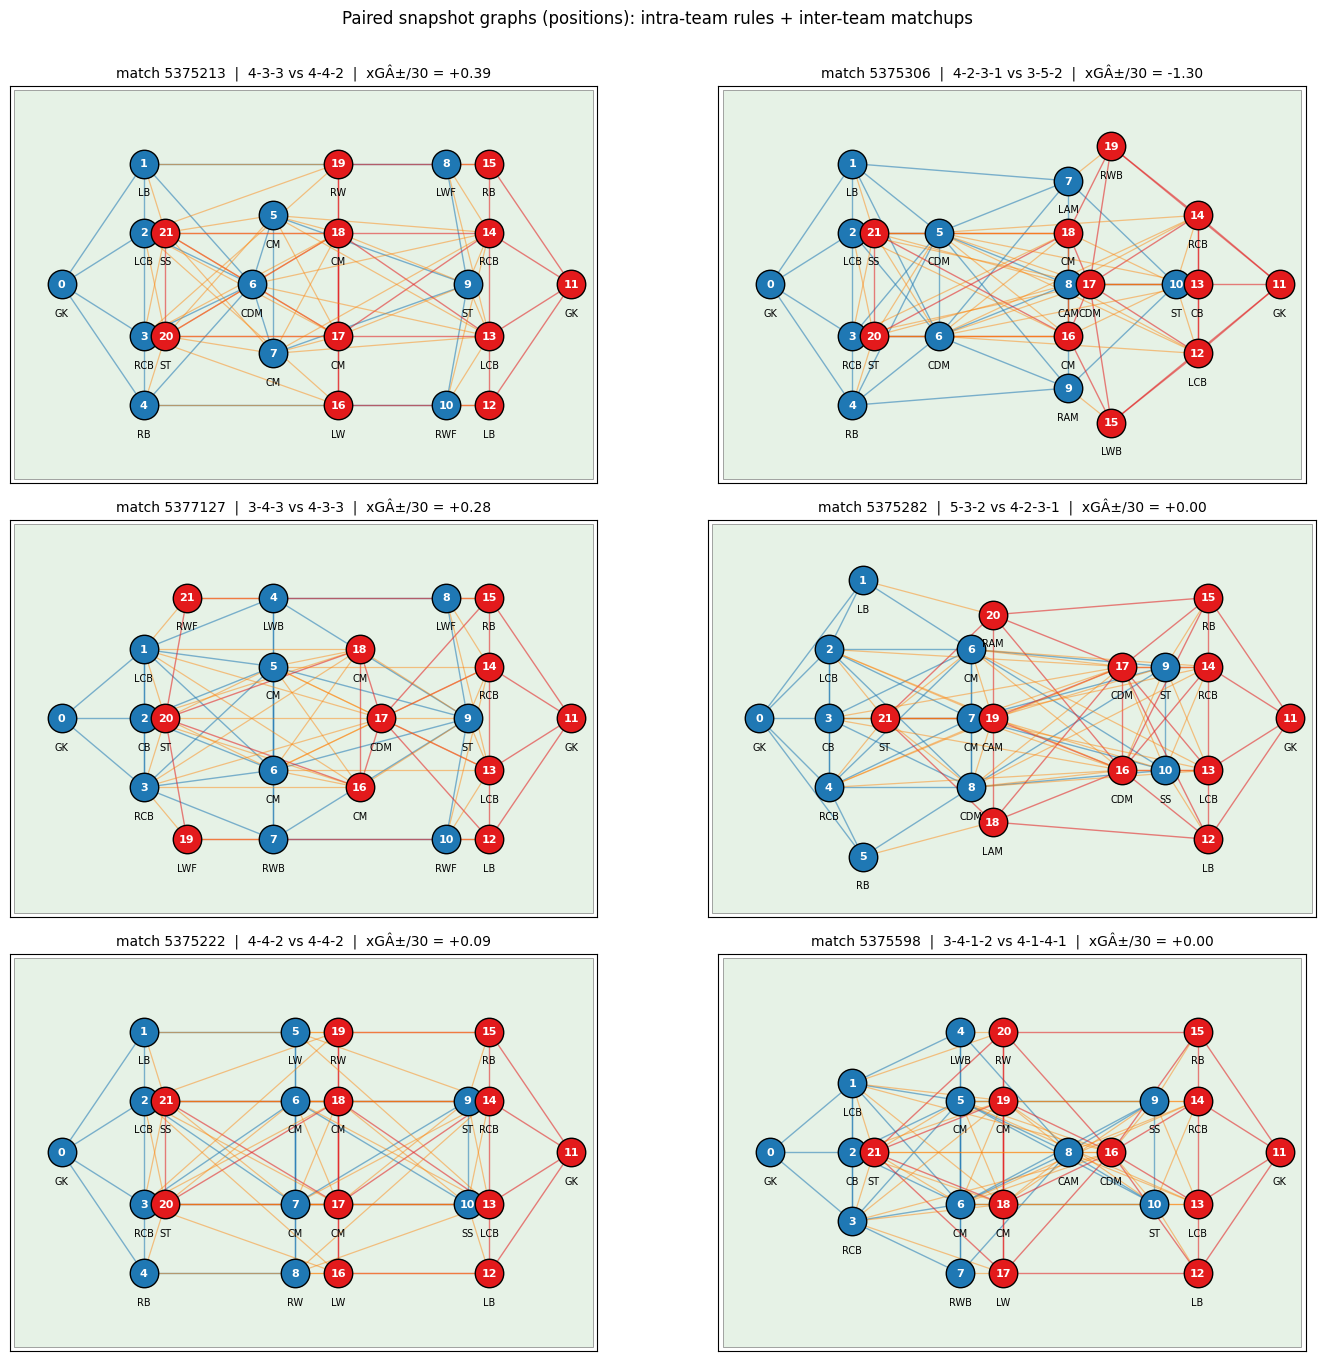

In [4]:
ncols = 2
nrows = math.ceil(len(examples) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7.5, nrows * 4.5))
axes = axes.flatten() if nrows * ncols > 1 else [axes]
for ax in axes[len(examples):]:
    ax.set_visible(False)

for ax, row in zip(axes, examples):
    t1_labels = [row[c] for c in pos_cols_1]
    t2_labels = [row[c] for c in pos_cols_2]
    f1 = row['team1_formation']
    f2 = row['team2_formation']
    y = row['xg_team1_minus_team2_per_30']
    title = f'match {int(row["match_id"])}  |  {f1} vs {f2}  |  xGÂ±/30 = {y:+.2f}'
    draw_paired_graph(ax, f1, t1_labels, f2, t2_labels, title=title)

fig.suptitle('Paired snapshot graphs (positions): intra-team rules + inter-team matchups', y=1.005)
fig.tight_layout()
plt.show()

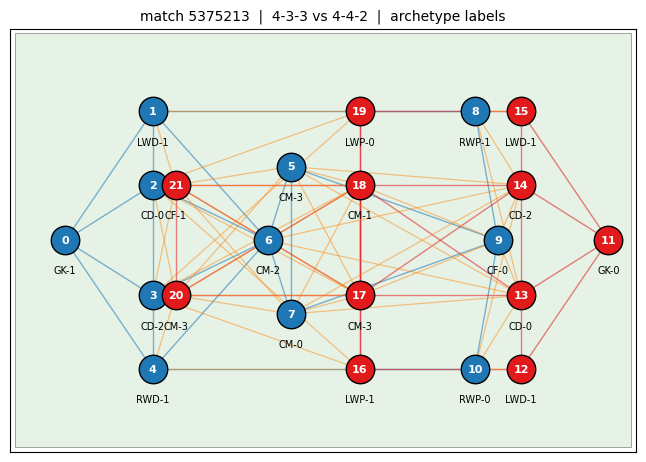

In [5]:
# Same first matchup, this time labeling nodes with archetype strings instead
# of position strings. Position labels are still passed so the matchup zones
# can be computed; only the displayed text changes.
row = examples[0]
t1_pos = [row[c] for c in pos_cols_1]
t2_pos = [row[c] for c in pos_cols_2]
t1_arch = [row[c] for c in arch_cols_1]
t2_arch = [row[c] for c in arch_cols_2]
fig, ax = plt.subplots(figsize=(9, 5.5))
draw_paired_graph(
    ax,
    row['team1_formation'], t1_pos,
    row['team2_formation'], t2_pos,
    display_labels_team1=t1_arch,
    display_labels_team2=t2_arch,
    title=f"match {int(row['match_id'])}  |  {row['team1_formation']} vs {row['team2_formation']}  |  archetype labels",
)
plt.show()